<a href="https://colab.research.google.com/github/nhjung-phd/TimeSeriesAnalysis/blob/main/notebooks/16_RandomForest_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Random Forest로 TSLA 방향성 예측 (분류)
이 노트북은 다음 거래일의 **상승/하락(이진 분류)**을 예측합니다.
시계열에서는 **시간 순서 보존**과 **정보누수 방지**가 핵심입니다.


## 0) 환경 준비
```bash
pip install yfinance
```


In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, roc_auc_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay
)


## 1) 데이터 수집 (2025-03-30 ~ 2026-03-30, 최근 1년)


In [2]:
# 데이터 수집 (최근 1년)
df = yf.download("TSLA", start="2025-03-30", end="2026-03-30", auto_adjust=True, progress=False).reset_index()
print("Rows:", len(df))
df.head()


Rows: 240


Price,Date,Close,High,Low,Open,Volume
Ticker,,TSLA,TSLA,TSLA,TSLA,TSLA
0,2025-03-31,259.160004,260.559998,243.360001,249.309998,134008900
1,2025-04-01,268.459991,277.450012,259.250000,263.799988,146486900
2,2025-04-02,282.760010,284.989990,251.270004,254.600006,212787800
3,2025-04-03,267.279999,276.299988,261.510010,265.290009,136174300
4,2025-04-04,239.429993,261.000000,236.000000,255.380005,181229400


## 2) 특징 생성(과거 정보만 사용)


In [3]:
# 특징(Feature) 생성: 과거 정보만 사용
df['ret1'] = df['Close'].pct_change()

for k in [1,2,3,5,10]:
    df[f'ret_lag{k}'] = df['ret1'].shift(k)

df['ma5']  = df['Close'].rolling(5).mean()
df['ma20'] = df['Close'].rolling(20).mean()
df['ma_gap'] = (df['ma5'] / df['ma20']) - 1.0
df['vol10'] = df['ret1'].rolling(10).std()

df = df.dropna().reset_index(drop=True)
print("After features rows:", len(df))


After features rows: 221


## 3) 타깃/분할(시간 순서 보존)


In [4]:
# 타깃: 다음날 상승(1) / 하락(0)
df['ret_next'] = df['Close'].pct_change().shift(-1)
df['y_bin'] = (df['ret_next'] > 0).astype(int)
df = df.dropna().reset_index(drop=True)

features = ['ret_lag1','ret_lag2','ret_lag3','ret_lag5','ret_lag10','ma_gap','vol10']
X = df[features]
y = df['y_bin']

# 시간 순서 보존 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
print("Train:", X_train.shape, "Test:", X_test.shape)


Train: (176, 7) Test: (44, 7)


## 4) 모델: Random Forest
- 여러 트리를 학습한 뒤 다수결(또는 평균 확률)로 예측합니다.
- 단일 트리보다 과적합이 줄고 안정적입니다.


In [5]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(
    n_estimators=300,
    max_depth=6,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1
)
model.fit(X_train, y_train)


RandomForestClassifier(max_depth=6, min_samples_leaf=10, n_estimators=300,
                       n_jobs=-1, random_state=42)

## 5) 평가


Accuracy: 0.5227
ROC-AUC : 0.5207

Classification report:
              precision    recall  f1-score   support

           0     0.6000    0.1364    0.2222        22
           1     0.5128    0.9091    0.6557        22

    accuracy                         0.5227        44
   macro avg     0.5564    0.5227    0.4390        44
weighted avg     0.5564    0.5227    0.4390        44



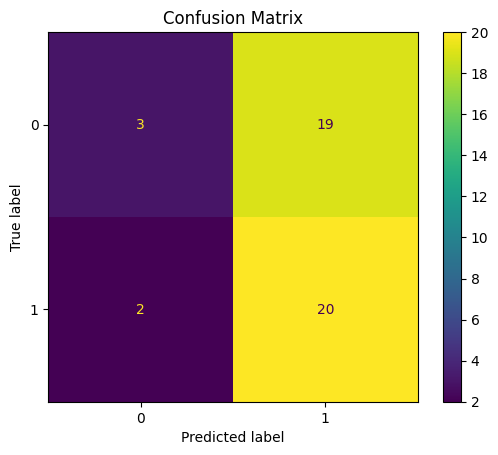

In [6]:
# 평가
y_pred = model.predict(X_test)
# 확률 예측이 가능한 모델이면 AUC도 계산
if hasattr(model, "predict_proba"):
    y_proba = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_proba)
else:
    y_proba = None
    auc = None

acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.4f}")
if auc is not None:
    print(f"ROC-AUC : {auc:.4f}")
print("\nClassification report:")
print(classification_report(y_test, y_pred, digits=4))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm).plot(values_format="d")
plt.title("Confusion Matrix")
plt.show()


## ✅ 마지막 시각화: ROC Curve + 변수 중요도(Top 10)


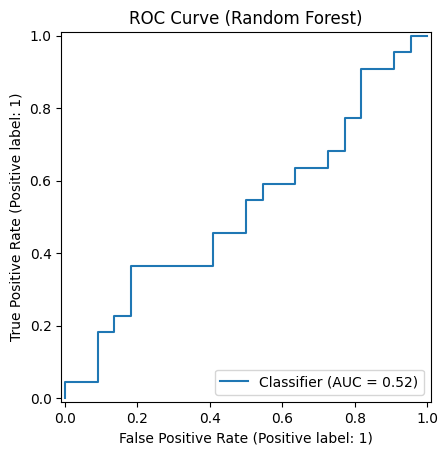

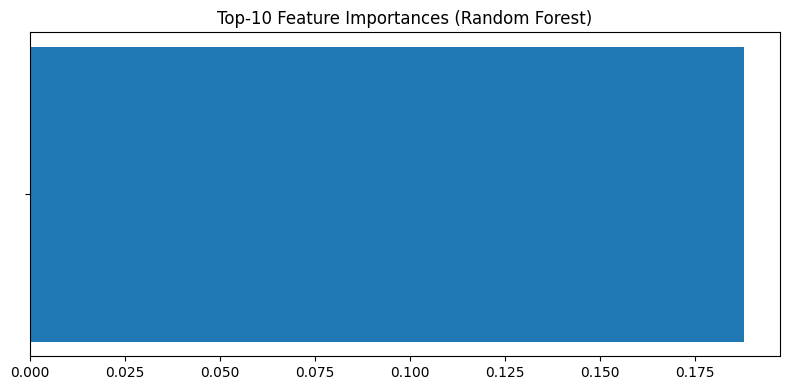

In [8]:
y_proba = model.predict_proba(X_test)[:, 1]
RocCurveDisplay.from_predictions(y_test, y_proba)
plt.title('ROC Curve (Random Forest)')
plt.show()

importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
top = importances.head(10).sort_values(ascending=True)
plt.figure(figsize=(8,4))
plt.barh(top.index.map(lambda x: x[1]), top.values)
plt.title('Top-10 Feature Importances (Random Forest)')
plt.tight_layout(); plt.show()

## 8) 방향 예측(Up/Down) 출력 + 다음 거래일 예측
아래는 분류 모델의 예측을 ‘방향’ 관점에서 요약하고,
마지막 관측치의 특징으로 다음 거래일(표시상 +1일)의 Up/Down을 출력합니다.
※ 실제 거래일 캘린더(휴장일)는 반영하지 않습니다.


In [9]:
import numpy as np
import pandas as pd

# 예측된 값 (0: 하락, 1: 상승)의 개수 계산
prediction_counts = np.bincount(y_pred)

# 예측 결과 출력
print(f"Predicted Down (하락): {prediction_counts[0] if len(prediction_counts) > 0 else 0} 건")
print(f"Predicted Up (상승): {prediction_counts[1] if len(prediction_counts) > 1 else 0} 건")

# 마지막 관측치로 '다음 거래일' 방향 예측(예: 오늘 기준 내일 Up/Down)
last_day_features = X.iloc[-1].values.reshape(1, -1)

# 모델별 입력 형식 처리: Pipeline(예: SVM)은 그대로 넣으면 scaler까지 적용됨
next_day_prediction = model.predict(last_day_features)

prediction_label = "상승 (Up)" if int(next_day_prediction[0]) == 1 else "하락 (Down)"

# 예측 날짜(단순히 마지막 날짜 + 1일로 표시)
last_date_in_df = df['Date'].iloc[-1]
predicted_date = last_date_in_df + pd.Timedelta(days=1)

print(f"다음 거래일 예측 (날짜: {predicted_date.strftime('%Y-%m-%d')}): {prediction_label}")


Predicted Down (하락): 5 건
Predicted Up (상승): 39 건
다음 거래일 예측 (날짜: 2026-03-13): 상승 (Up)


## ✅ 요약(3줄)
1) 분류는 ‘가격’을 맞추는 것이 아니라 ‘방향(Up/Down)’을 예측합니다.
2) 시계열에서는 **시간 분할**과 **누수 방지**가 성능보다 먼저입니다.
3) 정확도만 보지 말고 AUC/혼동행렬/기준선과 함께 해석하세요.
